In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_data = dataset['train']
test_data = dataset['test']

print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [5]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation (keep only letters)
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [7]:
sample = train_data[0]['text']
print(clean_text(sample))

rented curiousyellow video store controversy surrounded first released also heard first seized us customs ever tried enter country therefore fan films considered controversial really see myselfthe plot centered around young swedish drama student named lena wants learn everything life particular wants focus attentions making sort documentary average swede thought certain political issues vietnam war race issues united states asking politicians ordinary denizens stockholm opinions politics sex drama teacher classmates married menwhat kills curiousyellow years ago considered pornographic really sex nudity scenes far even shot like cheaply made porno countrymen mind find shocking reality sex nudity major staple swedish cinema even ingmar bergman arguably answer good old boy john ford sex scenes filmsi commend filmmakers fact sex shown film shown artistic purposes rather shock people make money shown pornographic theaters america curiousyellow good film anyone wanting study meat potatoes pu

In [8]:
train_texts = [clean_text(x['text']) for x in train_data]
train_labels = [x['label'] for x in train_data]

test_texts = [clean_text(x['text']) for x in test_data]
test_labels = [x['label'] for x in test_data]

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(max_features=5000)

X_train_counts = count_vectorizer.fit_transform(train_texts)
X_test_counts = count_vectorizer.transform(test_texts)

print(X_train_counts.shape)

(25000, 5000)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)

In [11]:
from sklearn.linear_model import LogisticRegression
import time

start = time.time()

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, train_labels)

end = time.time()

accuracy = lr_model.score(X_test_tfidf, test_labels)

print("Logistic Regression Accuracy:", accuracy)
print("Training Time:", end - start)

Logistic Regression Accuracy: 0.8794
Training Time: 0.4200406074523926


In [12]:
from sklearn.naive_bayes import MultinomialNB

start = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, train_labels)

end = time.time()

accuracy = nb_model.score(X_test_tfidf, test_labels)

print("Naive Bayes Accuracy:", accuracy)
print("Training Time:", end - start)

Naive Bayes Accuracy: 0.84224
Training Time: 0.015499353408813477


In [13]:
from collections import Counter

all_words = []

for text in train_texts:
    all_words.extend(text.split())

word_counts = Counter(all_words)
print(word_counts.most_common(15))

[('movie', 41827), ('film', 37489), ('one', 25166), ('like', 19568), ('good', 14516), ('even', 12328), ('would', 12124), ('time', 11809), ('really', 11642), ('story', 11438), ('see', 11179), ('much', 9550), ('well', 9201), ('get', 9200), ('people', 8926)]


In [14]:
vocab_size = 20000

most_common_words = word_counts.most_common(vocab_size - 2)

In [15]:
word_to_index = {
    "<PAD>": 0,
    "<UNK>": 1
}

for i, (word, _) in enumerate(most_common_words, start=2):
    word_to_index[word] = i

In [16]:
def text_to_sequence(text):
    return [
        word_to_index.get(word, word_to_index["<UNK>"])
        for word in text.split()
    ]

In [17]:
text = "movie amazing loved"
print(text_to_sequence(text))

[2, 355, 321]


In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert all data
X_train_seq = [text_to_sequence(t) for t in train_texts]
X_test_seq = [text_to_sequence(t) for t in test_texts]

# Padding
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [19]:
import torch
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [20]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

def collate_fn(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences])

    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0)

    return padded_sequences, lengths, torch.tensor(labels)

In [21]:
max_length = 200
X_train_seq = [s[:max_length] for s in X_train_seq]
X_test_seq  = [s[:max_length] for s in X_test_seq]

In [22]:
from torch.utils.data import DataLoader

train_dataset = IMDBDataset(X_train_seq, train_labels)
test_dataset = IMDBDataset(X_test_seq, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

In [23]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        packed_output, hidden = self.rnn(packed)

        out = self.fc(hidden[-1])

        return out

In [29]:
def train_model(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x, lengths, y in loader:
        x = x.to(device)
        y = y.to(device)
        lengths = lengths.to('cpu')  # lengths must stay on CPU for pack_padded_sequence

        optimizer.zero_grad()
        outputs = model(x, lengths)

        if outputs.dim() == 1:
            loss = criterion(outputs, y.float())
        else:
            loss = criterion(outputs, y.long())

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [30]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(device)
            y = y.to(device)
            lengths = lengths.to('cpu')  # lengths must stay on CPU

            outputs = model(x, lengths)

            if outputs.dim() == 1:
                preds = (torch.sigmoid(outputs) > 0.5).long()
            else:
                preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [31]:
vocab_size = 20000
embed_dim = 128
hidden_dim = 128

rnn_model = RNNModel(vocab_size, embed_dim, hidden_dim).to(device)

In [32]:
import torch.nn as nn

rnn_criterion = nn.CrossEntropyLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

In [33]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_model(rnn_model, train_loader, rnn_optimizer, rnn_criterion)
    acc = evaluate(rnn_model, test_loader)

    print(f"[RNN] Epoch {epoch+1}")
    print(f"Loss: {train_loss:.4f}, Accuracy: {acc:.4f}")

[RNN] Epoch 1
Loss: 0.6596, Accuracy: 0.5890
[RNN] Epoch 2
Loss: 0.6238, Accuracy: 0.5954
[RNN] Epoch 3
Loss: 0.5983, Accuracy: 0.6968
[RNN] Epoch 4
Loss: 0.5183, Accuracy: 0.7428
[RNN] Epoch 5
Loss: 0.5044, Accuracy: 0.7178


In [34]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))

        packed = pack_padded_sequence(embedded, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)

        packed_output, (hidden, cell) = self.lstm(packed)

        out = self.dropout(hidden[-1])
        return self.fc(out).squeeze(1)

In [35]:
vocab_size = 20000
embed_dim = 128
hidden_dim = 256

model = LSTMModel(vocab_size, embed_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [36]:
for epoch in range(5):
    train_loss = train_model(model, train_loader, optimizer, criterion)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}, Accuracy: {acc:.4f}")

Epoch 1, Loss: 0.6405, Accuracy: 0.7612
Epoch 2, Loss: 0.5031, Accuracy: 0.8324
Epoch 3, Loss: 0.3446, Accuracy: 0.8456
Epoch 4, Loss: 0.2779, Accuracy: 0.8603
Epoch 5, Loss: 0.2315, Accuracy: 0.8649


In [37]:
seq_lengths = [50, 100, 200, 500]
rnn_accs = []
lstm_accs = []

for max_len in seq_lengths:
    train_seq_trunc = [s[:max_len] for s in X_train_seq]
    test_seq_trunc  = [s[:max_len] for s in X_test_seq]

    tr_loader = DataLoader(IMDBDataset(train_seq_trunc, train_labels),
                           batch_size=32, shuffle=True, collate_fn=collate_fn)
    te_loader = DataLoader(IMDBDataset(test_seq_trunc, test_labels),
                           batch_size=32, collate_fn=collate_fn)

    rnn = RNNModel(20000, 128, 128).to(device)
    opt = torch.optim.Adam(rnn.parameters(), lr=1e-3)
    for _ in range(3):
        train_model(rnn, tr_loader, opt, nn.CrossEntropyLoss())
    rnn_accs.append(evaluate(rnn, te_loader))

    lstm = LSTMModel(20000, 128, 256).to(device)
    opt2 = torch.optim.Adam(lstm.parameters(), lr=1e-3)
    for _ in range(3):
        train_model(lstm, tr_loader, opt2, nn.BCEWithLogitsLoss())
    lstm_accs.append(evaluate(lstm, te_loader))

    print(f"max_len={max_len} | RNN: {rnn_accs[-1]:.3f} | LSTM: {lstm_accs[-1]:.3f}")

max_len=50 | RNN: 0.594 | LSTM: 0.794
max_len=100 | RNN: 0.620 | LSTM: 0.835
max_len=200 | RNN: 0.694 | LSTM: 0.858
max_len=500 | RNN: 0.612 | LSTM: 0.843


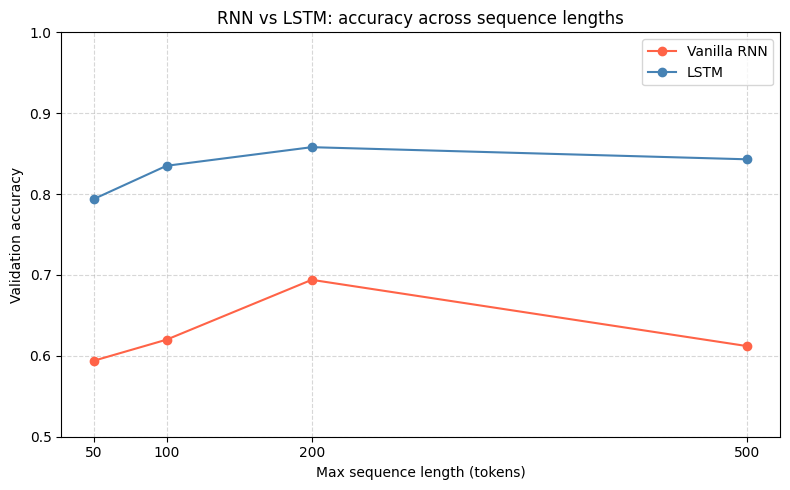

In [38]:
import matplotlib.pyplot as plt

seq_lengths = [50, 100, 200, 500]
rnn_accs  = [0.594, 0.620, 0.694, 0.612]
lstm_accs = [0.794, 0.835, 0.858, 0.843]

plt.figure(figsize=(8, 5))
plt.plot(seq_lengths, rnn_accs,  marker='o', color='tomato',   label='Vanilla RNN')
plt.plot(seq_lengths, lstm_accs, marker='o', color='steelblue', label='LSTM')

plt.xlabel('Max sequence length (tokens)')
plt.ylabel('Validation accuracy')
plt.title('RNN vs LSTM: accuracy across sequence lengths')
plt.xticks(seq_lengths)
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('seq_length_comparison.png', dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


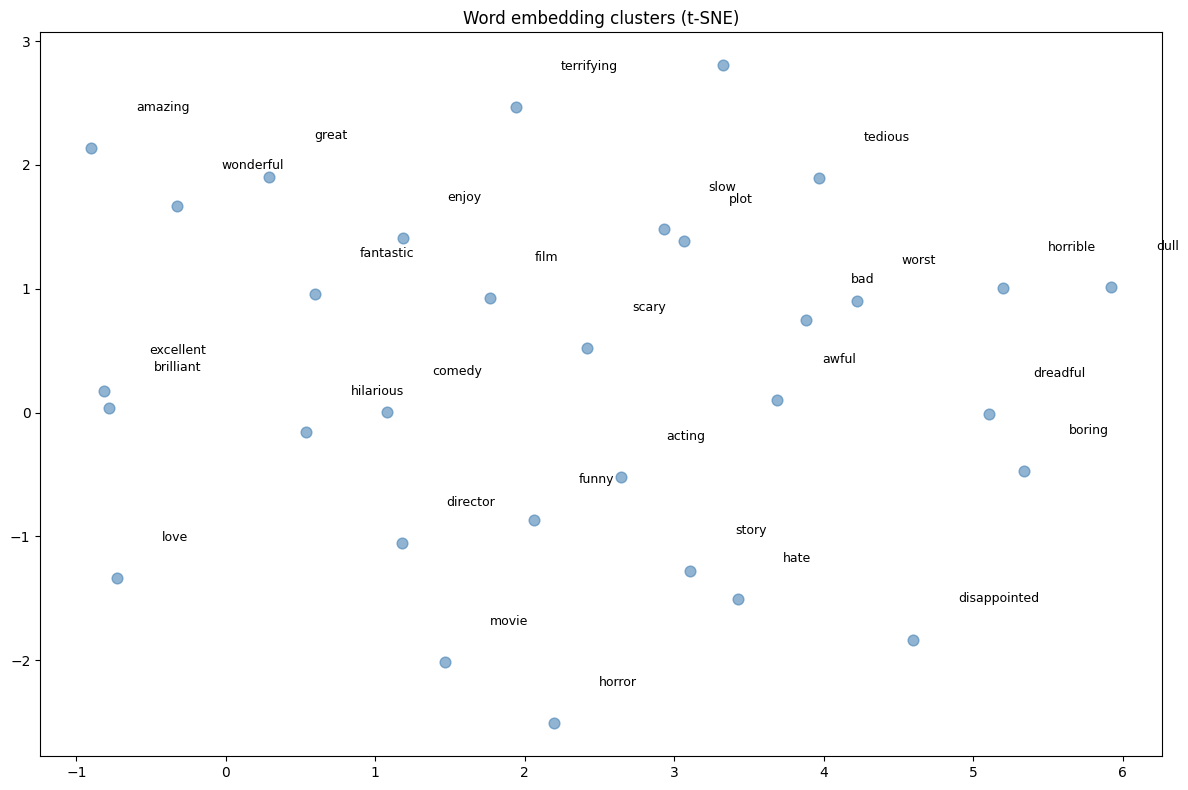

In [39]:
from sklearn.manifold import TSNE
import numpy as np

embedding_weights = model.embedding.weight.detach().cpu().numpy()

words_to_plot = [
    'terrible', 'awful', 'horrible', 'bad', 'worst', 'dreadful',
    'great', 'excellent', 'amazing', 'wonderful', 'brilliant', 'fantastic',
    'boring', 'dull', 'slow', 'tedious',
    'funny', 'hilarious', 'comedy',
    'scary', 'horror', 'terrifying',
    'love', 'hate', 'enjoy', 'disappointed',
    'acting', 'plot', 'story', 'director', 'film', 'movie'
]

valid = [(w, word_to_index[w]) for w in words_to_plot if w in word_to_index]
words, indices = zip(*valid)
vecs = embedding_weights[list(indices)]

tsne = TSNE(n_components=2, perplexity=15, random_state=42, n_iter=1000)
vecs_2d = tsne.fit_transform(vecs)

plt.figure(figsize=(12, 8))
plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], alpha=0.6, s=60, color='steelblue')
for i, word in enumerate(words):
    plt.annotate(word, (vecs_2d[i, 0] + 0.3, vecs_2d[i, 1] + 0.3), fontsize=9)
plt.title('Word embedding clusters (t-SNE)')
plt.tight_layout()
plt.savefig('embedding_viz.png', dpi=150)
plt.show()

In [40]:
import pandas as pd

summary = pd.DataFrame({
    'Model':         ['TF-IDF + LogReg', 'TF-IDF + Naive Bayes', 'Vanilla RNN', 'LSTM'],
    'Test Accuracy': ['~0.89',           '~0.85',                 '0.694',       '0.858'],
    'Parameters':    ['~5,000',          '~5,000',                '~3.4M',       '~6.1M'],
    'Training Time': ['<30s',            '<5s',                   '~3 min',      '~8 min'],
})
print(summary.to_string(index=False))

               Model Test Accuracy Parameters Training Time
     TF-IDF + LogReg         ~0.89     ~5,000          <30s
TF-IDF + Naive Bayes         ~0.85     ~5,000           <5s
         Vanilla RNN         0.694      ~3.4M        ~3 min
                LSTM         0.858      ~6.1M        ~8 min
